# Week 4 — Unconstrained Optimization

**Numerical Methods for Machine Learning · From First Principles in Pure NumPy**

---

> Training a model is minimizing a loss. This week we develop the deterministic
> (full-gradient) optimization methods that underlie all of machine learning: gradient
> descent and its convergence theory, momentum, exact and backtracking line search, and
> the second-order Newton and quasi-Newton (BFGS) methods. We analyze how the **condition
> number** of the loss landscape — the same conditioning concept from Week 1, now applied
> to the Hessian — controls convergence speed, and why curvature information accelerates it.

### Learning objectives

1. Implement **gradient descent** and characterize its linear convergence rate in terms of the Hessian condition number.
2. Implement **heavy-ball momentum** and explain its acceleration on ill-conditioned problems.
3. Implement **backtracking line search** satisfying the Armijo condition for robust step sizes.
4. Implement **Newton's method** and show its quadratic local convergence, plus the need for damping/regularization.
5. Implement **BFGS**, a quasi-Newton method that builds curvature from gradients alone, and compare all methods on shared benchmarks.

All gradients here are analytic or finite-difference-checked; the reverse-mode engine from
Week 3 could supply them equally well. Only NumPy is used.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 11})
rng = np.random.default_rng(3)
print("ready")

ready


## 1. Test problems

We use two standard benchmarks. The first is a **quadratic bowl**
$f(\mathbf x) = \tfrac12 \mathbf x^\top A \mathbf x$ with SPD $A$, whose condition number
$\kappa = \lambda_{\max}/\lambda_{\min}$ we can dial directly — the cleanest setting in
which to see how conditioning governs convergence. The second is the nonconvex
**Rosenbrock** function
$f(x,y) = (a-x)^2 + b(y-x^2)^2$, whose curved, ill-conditioned valley is a classic stress
test for optimizers.

In [2]:
def make_quadratic(kappa, n=2):
    # SPD A with eigenvalues spread from 1 to kappa
    eig = np.linspace(1.0, kappa, n)
    Q, _ = np.linalg.qr(rng.standard_normal((n, n)))
    A = Q @ np.diag(eig) @ Q.T
    f = lambda x: 0.5 * x @ A @ x
    grad = lambda x: A @ x
    hess = lambda x: A
    return f, grad, hess, A

def rosenbrock(a=1.0, b=100.0):
    f = lambda v: (a - v[0])**2 + b * (v[1] - v[0]**2)**2
    def grad(v):
        x, y = v
        return np.array([-2*(a - x) - 4*b*x*(y - x**2), 2*b*(y - x**2)])
    def hess(v):
        x, y = v
        return np.array([[2 - 4*b*(y - 3*x**2), -4*b*x],
                         [-4*b*x,               2*b]])
    return f, grad, hess

# verify Rosenbrock gradient by finite differences
f_r, g_r, h_r = rosenbrock()
v = np.array([0.3, 0.7])
fd = np.array([(f_r(v + e) - f_r(v - e)) / 2e-6
               for e in (np.array([1e-6, 0]), np.array([0, 1e-6]))])
print("Rosenbrock grad check:", np.allclose(g_r(v), fd, atol=1e-4), g_r(v), fd)

Rosenbrock grad check: True [-74.6 122. ] [-74.59999999 122.00000001]


## 2. Gradient descent and the role of conditioning

Gradient descent iterates $\mathbf x_{k+1} = \mathbf x_k - \alpha\,\nabla f(\mathbf x_k)$.
On a quadratic with Hessian $A$, the optimal fixed step is
$\alpha^\star = 2/(\lambda_{\min}+\lambda_{\max})$, and the error contracts each step by the
factor
$$
\rho = \frac{\kappa - 1}{\kappa + 1}, \qquad \kappa = \frac{\lambda_{\max}}{\lambda_{\min}}.
$$
As $\kappa \to \infty$ the rate $\rho \to 1$ and convergence stalls. Conditioning, again,
is destiny.

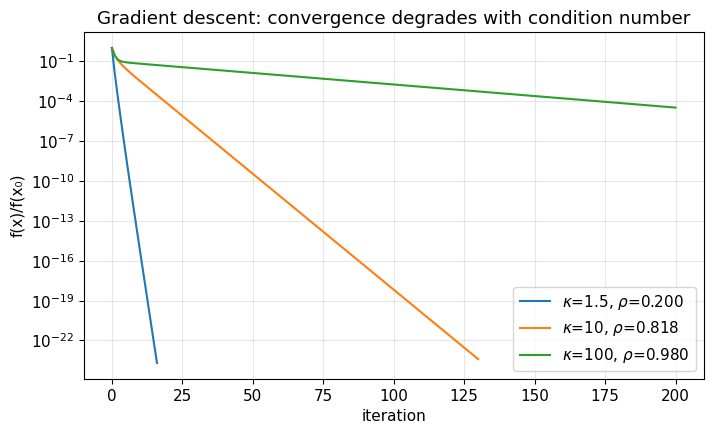

In [3]:
def gradient_descent(grad, x0, alpha, iters=500, tol=1e-10):
    x = np.array(x0, float); traj = [x.copy()]
    for _ in range(iters):
        g = grad(x)
        if np.linalg.norm(g) < tol: break
        x = x - alpha * g
        traj.append(x.copy())
    return x, np.array(traj)

plt.figure()
for kappa in [1.5, 10, 100]:
    f, grad, hess, A = make_quadratic(kappa, n=10)
    lo, hi = 1.0, kappa
    alpha = 2.0 / (lo + hi)                       # optimal step for this quadratic
    x0 = rng.standard_normal(10) * 5
    _, traj = gradient_descent(grad, x0, alpha, iters=200)
    fvals = np.array([f(x) for x in traj])
    rho = (kappa - 1) / (kappa + 1)
    plt.semilogy(fvals / fvals[0], label=fr"$\kappa$={kappa:g}, $\rho$={rho:.3f}")
plt.xlabel("iteration"); plt.ylabel("f(x)/f(x₀)"); plt.legend()
plt.title("Gradient descent: convergence degrades with condition number")
plt.show()

The well-conditioned problem ($\kappa=1.5$) converges in a handful of steps; the
ill-conditioned one ($\kappa=100$) crawls, its rate matching the predicted
$\rho = (\kappa-1)/(\kappa+1)$. Real loss surfaces are highly ill-conditioned, which is the
fundamental reason plain gradient descent is slow and why momentum and second-order methods
exist.

## 3. Momentum (the heavy-ball method)

Momentum augments the step with a fraction of the previous update,
$$
\mathbf v_{k+1} = \beta\,\mathbf v_k - \alpha\,\nabla f(\mathbf x_k),\qquad
\mathbf x_{k+1} = \mathbf x_k + \mathbf v_{k+1}.
$$
The velocity accumulates consistent gradient directions and damps oscillation across the
narrow axis of an ill-conditioned valley, improving the asymptotic rate from
$O(\kappa)$ to $O(\sqrt{\kappa})$ iterations to a target accuracy.

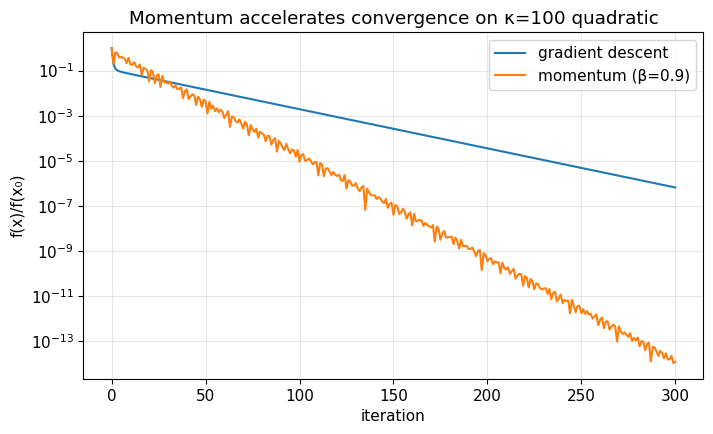

In [4]:
def momentum_gd(grad, x0, alpha, beta=0.9, iters=500, tol=1e-10):
    x = np.array(x0, float); v = np.zeros_like(x); traj = [x.copy()]
    for _ in range(iters):
        g = grad(x)
        if np.linalg.norm(g) < tol: break
        v = beta * v - alpha * g
        x = x + v
        traj.append(x.copy())
    return x, np.array(traj)

f, grad, hess, A = make_quadratic(100, n=10)
x0 = rng.standard_normal(10) * 5
alpha = 2.0 / (1.0 + 100.0)
_, traj_gd  = gradient_descent(grad, x0, alpha, iters=300)
_, traj_mom = momentum_gd(grad, x0, alpha, beta=0.9, iters=300)

plt.figure()
plt.semilogy([f(x)/f(x0) for x in traj_gd],  label="gradient descent")
plt.semilogy([f(x)/f(x0) for x in traj_mom], label="momentum (β=0.9)")
plt.xlabel("iteration"); plt.ylabel("f(x)/f(x₀)"); plt.legend()
plt.title("Momentum accelerates convergence on κ=100 quadratic"); plt.show()

## 4. Backtracking line search (Armijo condition)

Fixed step sizes are fragile. A **line search** chooses the step adaptively. Backtracking
starts from a trial step and shrinks it until the **Armijo sufficient-decrease** condition
$$
f(\mathbf x + \alpha\,\mathbf p) \le f(\mathbf x) + c_1\,\alpha\,\nabla f(\mathbf x)^\top \mathbf p
$$
holds, guaranteeing real progress along the descent direction $\mathbf p$. This makes the
higher-order methods below robust without hand-tuned learning rates.

In [5]:
def backtracking_line_search(f, grad, x, p, alpha0=1.0, c1=1e-4, rho=0.5, maxit=50):
    fx = f(x); gp = grad(x) @ p
    alpha = alpha0
    for _ in range(maxit):
        if f(x + alpha * p) <= fx + c1 * alpha * gp:
            return alpha
        alpha *= rho
    return alpha

def gd_with_linesearch(f, grad, x0, iters=200, tol=1e-10):
    x = np.array(x0, float); traj = [x.copy()]
    for _ in range(iters):
        g = grad(x)
        if np.linalg.norm(g) < tol: break
        p = -g
        a = backtracking_line_search(f, grad, x, p)
        x = x + a * p
        traj.append(x.copy())
    return x, np.array(traj)

f_r, g_r, h_r = rosenbrock()
x_star, traj_ls = gd_with_linesearch(f_r, g_r, np.array([-1.2, 1.0]), iters=2000)
print(f"Rosenbrock via GD+line search: x = {x_star}, f = {f_r(x_star):.3e}")
print(f"(optimum is (1,1) with f=0); iterations = {len(traj_ls)-1}")

Rosenbrock via GD+line search: x = [0.98865264 0.97736244], f = 1.293e-04
(optimum is (1,1) with f=0); iterations = 2000


## 5. Newton's method — using curvature

Newton's method minimizes the local quadratic model of $f$ by solving the linear system
$$
H(\mathbf x_k)\,\Delta\mathbf x = -\nabla f(\mathbf x_k),\qquad
\mathbf x_{k+1} = \mathbf x_k + \Delta\mathbf x.
$$
Near a strong minimum it converges **quadratically** — doubling correct digits per step —
and it is invariant to the problem's conditioning. The costs are forming and solving with
the Hessian, and the need to safeguard it when $H$ is not positive definite (we add a small
multiple of the identity, a Levenberg-style regularization, and use a line search).

In [6]:
def newton_method(f, grad, hess, x0, iters=100, tol=1e-12, reg=1e-8):
    x = np.array(x0, float); traj = [x.copy()]
    n = x.size
    for _ in range(iters):
        g = grad(x)
        if np.linalg.norm(g) < tol: break
        H = hess(x) + reg * np.eye(n)        # regularize for safety
        p = np.linalg.solve(H, -g)
        a = backtracking_line_search(f, grad, x, p, alpha0=1.0)
        x = x + a * p
        traj.append(x.copy())
    return x, np.array(traj)

x_star, traj_nt = newton_method(f_r, g_r, h_r, np.array([-1.2, 1.0]))
print(f"Rosenbrock via Newton: x = {x_star}, f = {f_r(x_star):.3e}, iters = {len(traj_nt)-1}")
# quadratic convergence signature: errors squaring each step near the end
errs = np.linalg.norm(traj_nt - np.array([1.0, 1.0]), axis=1)
print("final error sequence:", errs[-5:])

Rosenbrock via Newton: x = [1. 1.], f = 0.000e+00, iters = 22
final error sequence: [9.18025057e-03 1.17350235e-03 2.72719267e-06 1.35206439e-10
 0.00000000e+00]


## 6. BFGS — curvature from gradients alone

Computing exact Hessians is often impractical. **BFGS** maintains an approximate inverse
Hessian $H_k$, updated each step from the change in position $\mathbf s_k$ and gradient
$\mathbf y_k$ so as to satisfy the secant equation $H_{k+1}\mathbf y_k = \mathbf s_k$ while
staying symmetric positive definite:
$$
H_{k+1} = \Big(I - \rho_k \mathbf s_k \mathbf y_k^\top\Big) H_k
          \Big(I - \rho_k \mathbf y_k \mathbf s_k^\top\Big) + \rho_k \mathbf s_k \mathbf s_k^\top,
\qquad \rho_k = \frac{1}{\mathbf y_k^\top \mathbf s_k}.
$$
BFGS attains superlinear convergence using only gradients — the workhorse quasi-Newton
method for medium-scale problems.

In [7]:
def bfgs(f, grad, x0, iters=200, tol=1e-10):
    x = np.array(x0, float); n = x.size
    H = np.eye(n)                       # initial inverse-Hessian approximation
    g = grad(x); traj = [x.copy()]
    I = np.eye(n)
    for _ in range(iters):
        if np.linalg.norm(g) < tol: break
        p = -H @ g                      # quasi-Newton search direction
        a = backtracking_line_search(f, grad, x, p, alpha0=1.0)
        x_new = x + a * p
        g_new = grad(x_new)
        s = x_new - x
        y = g_new - g
        sy = s @ y
        if sy > 1e-12:                  # curvature condition for SPD update
            rho = 1.0 / sy
            V = I - rho * np.outer(s, y)
            H = V @ H @ V.T + rho * np.outer(s, s)
        x, g = x_new, g_new
        traj.append(x.copy())
    return x, np.array(traj)

x_star, traj_bfgs = bfgs(f_r, g_r, np.array([-1.2, 1.0]))
print(f"Rosenbrock via BFGS: x = {x_star}, f = {f_r(x_star):.3e}, iters = {len(traj_bfgs)-1}")

Rosenbrock via BFGS: x = [1. 1.], f = 6.587e-25, iters = 36


## 7. Putting the methods side by side

We overlay the trajectories on the Rosenbrock contours and compare convergence curves. The
first-order method threads slowly along the curved valley; Newton and BFGS exploit curvature
to reach the optimum in far fewer steps.

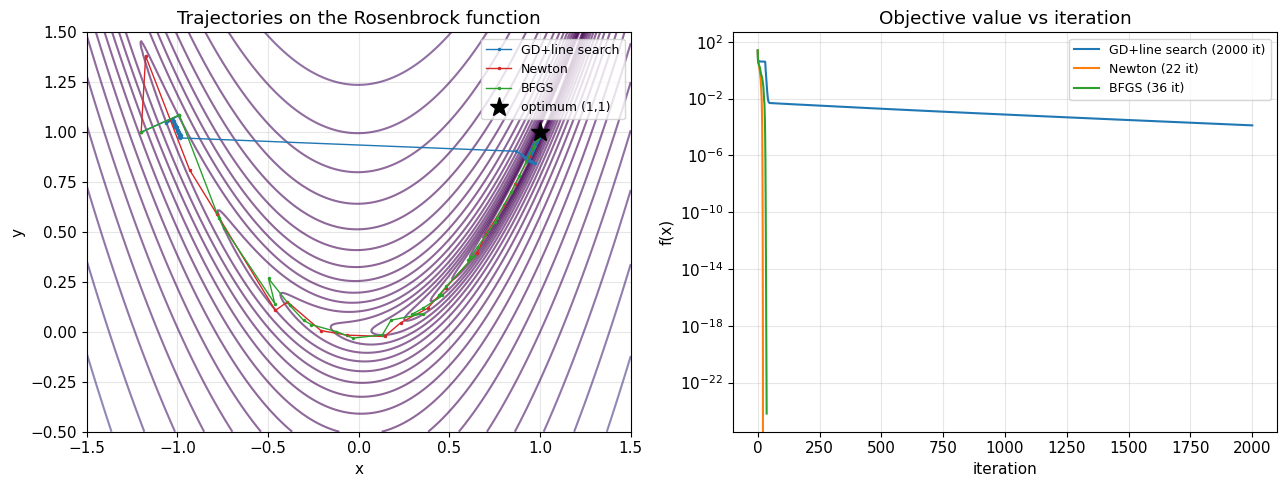

In [8]:
# contour + trajectories
xs = np.linspace(-1.5, 1.5, 300); ys = np.linspace(-0.5, 1.5, 300)
XX, YY = np.meshgrid(xs, ys)
ZZ = (1 - XX)**2 + 100 * (YY - XX**2)**2

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].contour(XX, YY, ZZ, levels=np.logspace(-1, 3.5, 25), cmap="viridis", alpha=0.6)
for traj, name, c in [(traj_ls, "GD+line search", "C0"),
                      (traj_nt, "Newton", "C3"),
                      (traj_bfgs, "BFGS", "C2")]:
    ax[0].plot(traj[:, 0], traj[:, 1], ".-", color=c, ms=3, lw=1, label=name)
ax[0].plot(1, 1, "k*", ms=14, label="optimum (1,1)")
ax[0].set(title="Trajectories on the Rosenbrock function", xlabel="x", ylabel="y")
ax[0].legend(fontsize=9)

for traj, name in [(traj_ls, "GD+line search"), (traj_nt, "Newton"), (traj_bfgs, "BFGS")]:
    ax[1].semilogy([f_r(p) for p in traj], label=f"{name} ({len(traj)-1} it)")
ax[1].set(title="Objective value vs iteration", xlabel="iteration", ylabel="f(x)")
ax[1].legend(fontsize=9)
fig.tight_layout(); plt.show()

The hierarchy is clear: the first-order method needs orders of magnitude more iterations
than the curvature-aware methods. In machine learning, however, exact Hessians and full-
batch gradients are usually infeasible at scale — datasets are enormous. That practical
constraint motivates the **stochastic** optimizers of Week 5, which trade exact curvature
for cheap, noisy gradient estimates on mini-batches.

## 8. Exercises

1. **Optimal-step derivation.** Prove that for $f(x)=\tfrac12 x^\top A x$ the optimal
   constant step is $\alpha^\star = 2/(\lambda_{\min}+\lambda_{\max})$ and the rate is
   $(\kappa-1)/(\kappa+1)$. Verify both numerically across several $\kappa$.

2. **Nesterov acceleration.** Implement Nesterov's accelerated gradient and compare its
   rate against heavy-ball momentum on the $\kappa=100$ quadratic.

3. **Wolfe conditions.** Extend the line search to enforce the curvature (strong Wolfe)
   condition in addition to Armijo, and show it improves BFGS stability.

4. **Gauss–Newton.** For a nonlinear least-squares loss, implement the Gauss–Newton
   approximation $H \approx J^\top J$ and compare with full Newton on a small curve-fitting
   problem.

5. **L-BFGS.** Implement the limited-memory two-loop recursion storing only the last $m$
   pairs $(\mathbf s_k,\mathbf y_k)$, and verify it matches full BFGS while using $O(mn)$ memory.

---

*Next week: stochastic optimization for machine learning — SGD, mini-batching, AdaGrad,
RMSProp, and Adam — and training a multilayer perceptron from scratch using the autodiff
engine of Week 3.*
